# Decision Tree, Random Forest and AdaBoost Experimentation

In [82]:
#@title Import Full Bank File

import pandas as pd

# Read Banking CSV file
url = 'https://raw.githubusercontent.com/johnnydrodriguez/data622/refs/heads/main/bank_full.csv'
bank_df = pd.read_csv(url, delimiter=';')

# Display the first 5 rows
display(bank_df.head())

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Dataset Encoding for Experiments

To ensure consistency across the experiments and to meet the requirements of the Decision Tree, Random Forest and AdaBoost models, we prepare the dataset for modeling.  To do this we:

*   separate the dataset into features (X) and the target variable (y).
*   transform the target variable from categorical strings into a numerical binary format.

We apply one-hot encoding to the feature set, converting all categorical text data into a numerical format that the models can process. The drop_first=True argument is used to prevent multicollinearity by removing one redundant column per feature.

**We will use this encoded data set for all of the models below.**

In [83]:
# Separate features (X) and target (y)
X = bank_df.drop('y', axis=1)
y = bank_df['y']

# Encode the target variable 'y' into numerical format (0 for 'no', 1 for 'yes')
y_encoded = y.apply(lambda x: 1 if x == 'yes' else 0)

# Perform one-hot encoding on features (X) with drop_first=True
X_processed = pd.get_dummies(X, drop_first=True)

# Display the first 5 rows of the processed features
display(X_processed.head())

# Display the first 5 rows of the encoded target
display(y_encoded.head())

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False


,y
0,0
1,0
2,0
3,0
4,0


### Decision Trees - Tree Depth

**Experiment 1:**  We control the Tree Depth (max_depth) to control a Decision Tree's complexity. The max_depth hyperparameter dictates the maximum number of levels the tree can grow.

**Hypothesis:** A simple, unconstrained tree will likely overfit the training data, learning its noise. By limiting the tree's depth, we can create a more generalized model that performs better on unseen test data, even if its accuracy on the training data is lower.

To test our hypothesis, we will run these steps and compare the results:

*   Let the tree grow to its maximum possible depth (setting max_depth=None).
*   Constrain the tree to a shallow depth (e.g., max_depth=3 or max_depth=4 or max_depth=4).

In [84]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Split data into training and testing sets
# We use this test / train split dataset for all models moving forward
X_train, X_test, y_train, y_test = train_test_split(X_processed, y_encoded, test_size=0.3, random_state=42)

# Decision Tree with max_depth=None (unconstrained)
tree_unconstrained = DecisionTreeClassifier(random_state=42)
tree_unconstrained.fit(X_train, y_train)
y_pred_unconstrained = tree_unconstrained.predict(X_test)
accuracy_unconstrained = accuracy_score(y_test, y_pred_unconstrained)

print(f"Accuracy for unconstrained tree (max_depth=None): {accuracy_unconstrained:.4f}")

# Decision Tree with constrained depth (e.g., max_depth=4)
tree_constrained = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_constrained.fit(X_train, y_train)
y_pred_constrained = tree_constrained.predict(X_test)
accuracy_constrained = accuracy_score(y_test, y_pred_constrained)

print(f"Accuracy for constrained tree (max_depth=4): {accuracy_constrained:.4f}")

Accuracy for unconstrained tree (max_depth=None): 0.8899
Accuracy for constrained tree (max_depth=4): 0.9122


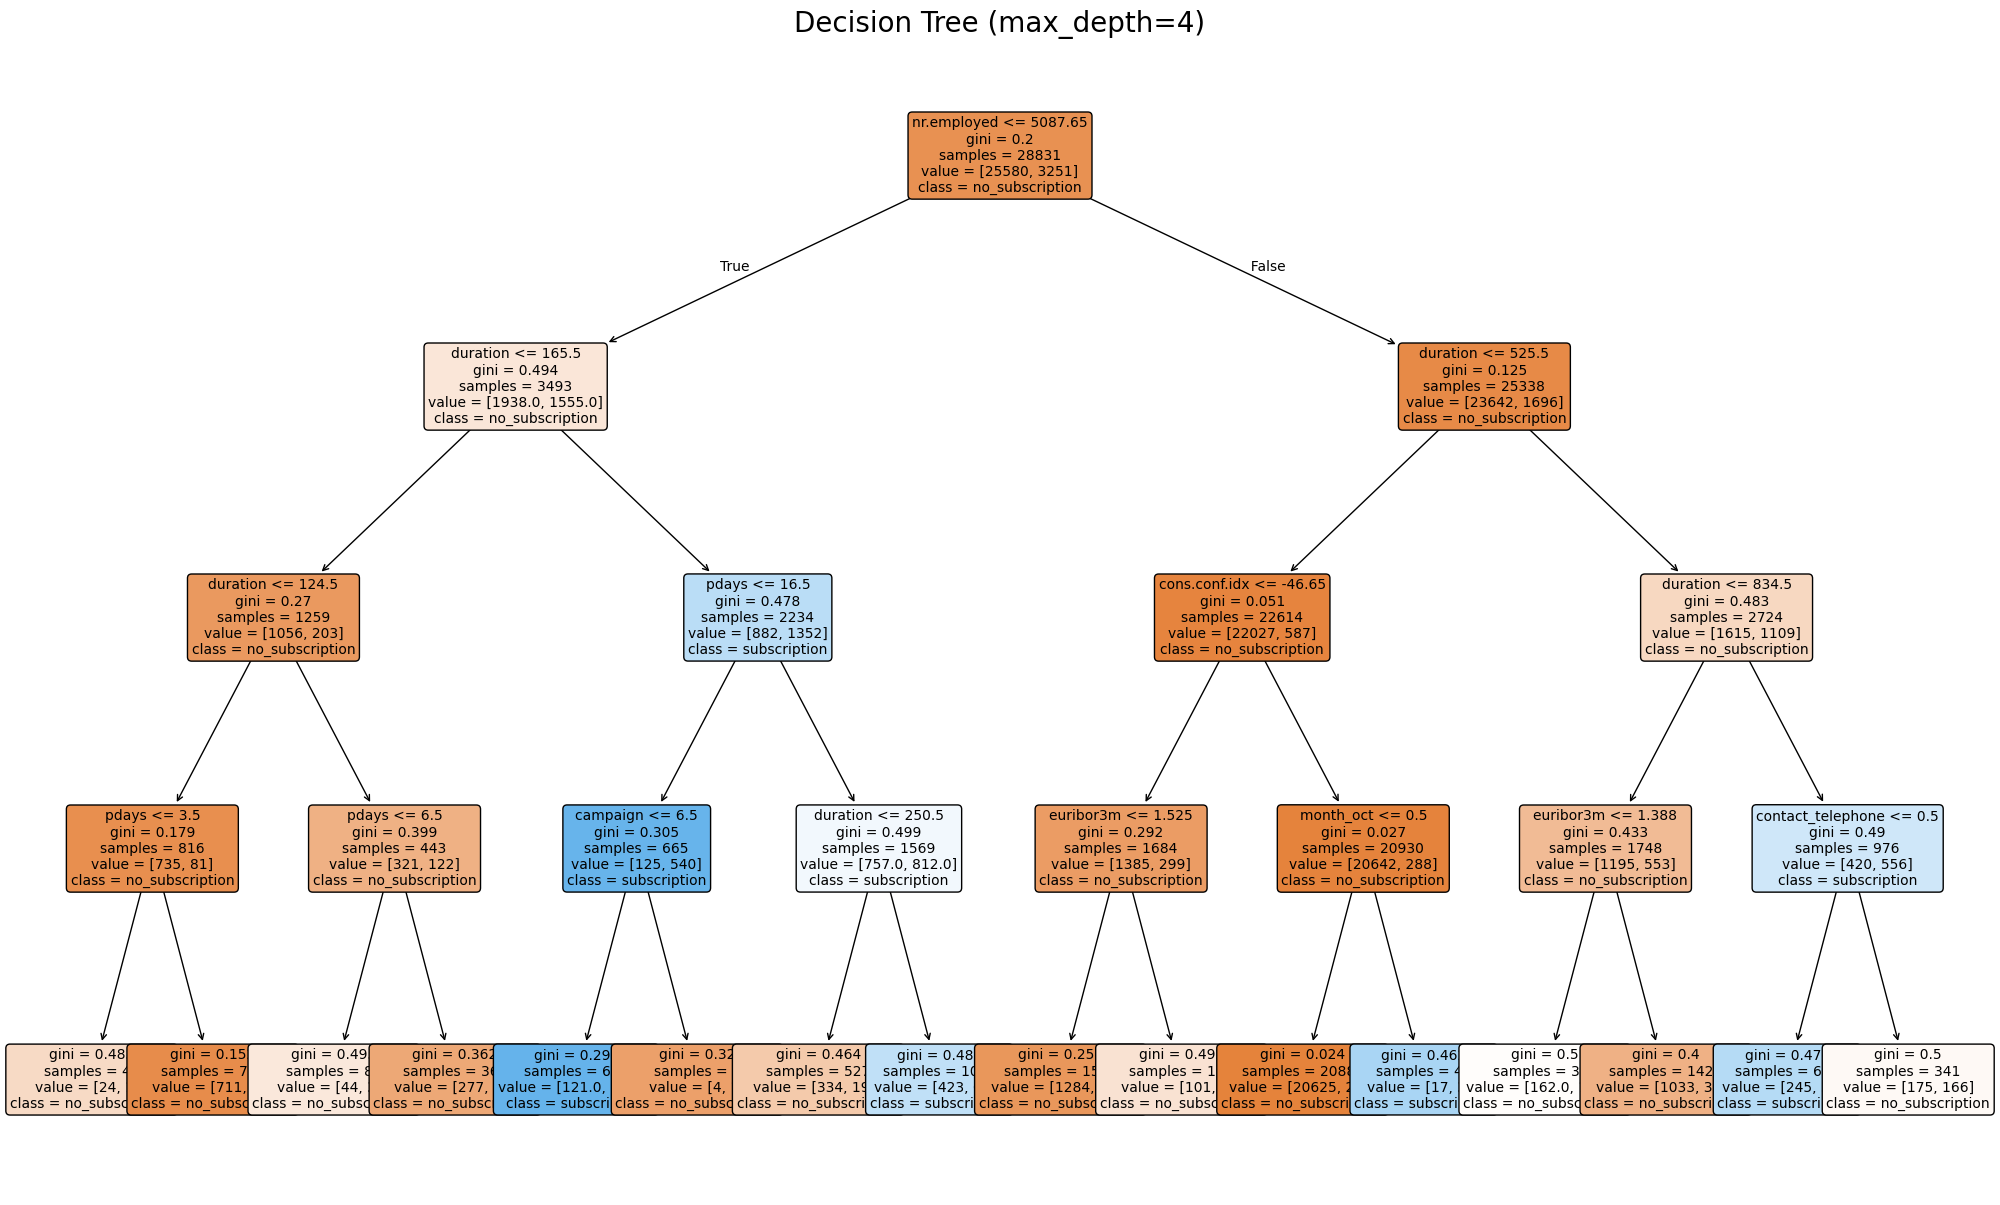

In [85]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Visualize the max_depth=4 Tree
plt.figure(figsize=(25, 15))

plot_tree(tree_constrained,
          filled=True,
          feature_names=X_processed.columns,
          class_names=['no_subscription', 'subscription'],
          rounded=True,
          fontsize=10,
          max_depth=4)

plt.title("Decision Tree (max_depth=4)", fontsize=20)
plt.show()

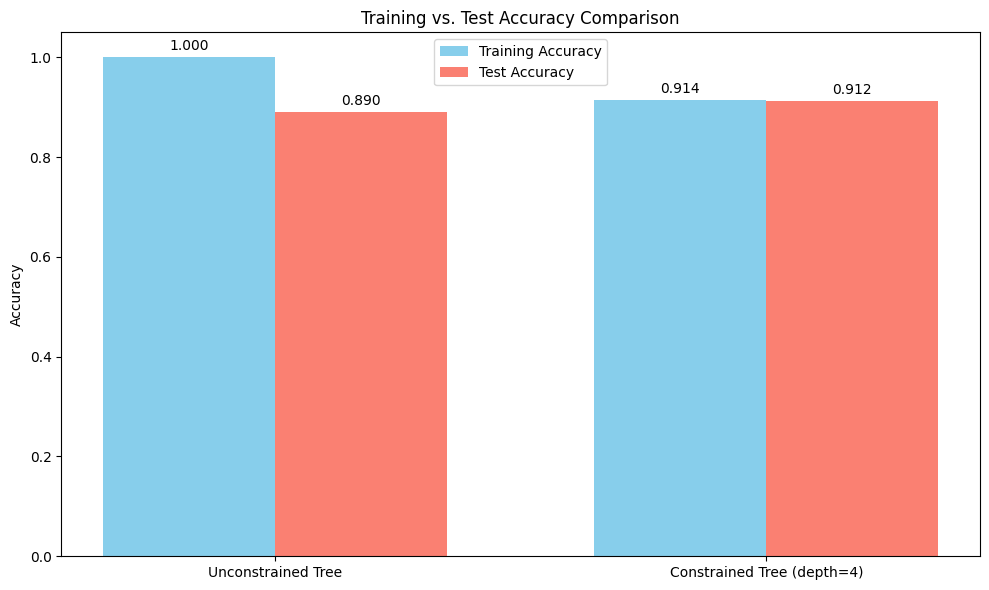

In [86]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate Training Accuracies
train_acc_unconstrained = tree_unconstrained.score(X_train, y_train)
train_acc_constrained = tree_constrained.score(X_train, y_train)

# Get Test Accuracies (calculated previously)
test_acc_unconstrained = accuracy_score(y_test, y_pred_unconstrained)
test_acc_constrained = accuracy_score(y_test, y_pred_constrained)

# Create the Bar Chart
labels = ['Unconstrained Tree', 'Constrained Tree (depth=4)']
train_accuracies = [train_acc_unconstrained, train_acc_constrained]
test_accuracies = [test_acc_unconstrained, test_acc_constrained]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, train_accuracies, width, label='Training Accuracy', color='skyblue')
rects2 = ax.bar(x + width/2, test_accuracies, width, label='Test Accuracy', color='salmon')

ax.set_ylabel('Accuracy')
ax.set_title('Training vs. Test Accuracy Comparison')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.bar_label(rects1, padding=3, fmt='%.3f')
ax.bar_label(rects2, padding=3, fmt='%.3f')
ax.set_ylim(0, 1.05)

fig.tight_layout()
plt.show()

#### Summary of Decision Tree - Max Depth Results

In Decision Tree Max Depth experiment, we compared an unconstrained decision tree (`max_depth=None`) with a constrained tree (`max_depth=4`).

*   The **constrained tree (max_depth=4)** achieved a test accuracy of {accuracy_constrained:.4f}, which was higher than the unconstrained tree's test accuracy of {accuracy_unconstrained:.4f}. This constrained model is significantly more interpretable due to its limited depth.

*   The **unconstrained tree**, while achieving perfect accuracy on the training data ({train_acc_unconstrained:.4f}), showed a noticeable drop in performance on the test data ({test_acc_unconstrained:.4f}), indicating overfitting.

*   The **constrained tree**, with similar training accuracy ({train_acc_constrained:.4f}) and test accuracy ({test_acc_constrained:.4f}), demonstrated less overfitting and better generalization to unseen data.

These results support the hypothesis that controlling tree depth can improve model performance on test data by reducing overfitting and increasing interpretability.

Note that a constrained tree (at least one with smaller depth values) is the only directly interpretable tree visualization.  Greater tree depths make the tree significantly less interpretable and an unconstrained tree visualization may be impracticably large to reasonably visualize.  Random Forests and AdaBoost Forest cannot be reasonbably visually interpreted due to their complexity.  While a Decision Tree may be ideal for its explainability, it typically cannot reliably model unseen data in real world data sets.

### Decision Trees -  Pruning with Minimum Leaf Size

**Experiment 2:** Prevent the tree from creating leaves that contain very few samples. Our second experiment prunes the tree by stopping it from making splits that overly specific.

**Hypothesis:** Forcing leaves to contain a minimum number of samples will prevent the model from creating hyper-specific rules that only apply to a handful of instances in the training set.  This approach should generalize better to unseen data.

To test our hypothesis, we will run these steps and compare the results:

*   Use the default setting (min_samples_leaf=1) to allows the tree to create leaves with just a single sample.
*  Set a larger value (min_samples_leaf=50)

In [87]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Decision Tree with min_samples_leaf=1 (default)
tree_min_samples_1 = DecisionTreeClassifier(min_samples_leaf=1, random_state=42)
tree_min_samples_1.fit(X_train, y_train)
y_pred_min_samples_1 = tree_min_samples_1.predict(X_test)
accuracy_min_samples_1 = accuracy_score(y_test, y_pred_min_samples_1)

print(f"Accuracy for tree with min_samples_leaf=1: {accuracy_min_samples_1:.4f}")

# Decision Tree with min_samples_leaf=50
tree_min_samples_50 = DecisionTreeClassifier(min_samples_leaf=50, random_state=42)
tree_min_samples_50.fit(X_train, y_train)
y_pred_min_samples_50 = tree_min_samples_50.predict(X_test)
accuracy_min_samples_50 = accuracy_score(y_test, y_pred_min_samples_50)

print(f"Accuracy for tree with min_samples_leaf=50: {accuracy_min_samples_50:.4f}")

Accuracy for tree with min_samples_leaf=1: 0.8899
Accuracy for tree with min_samples_leaf=50: 0.9141


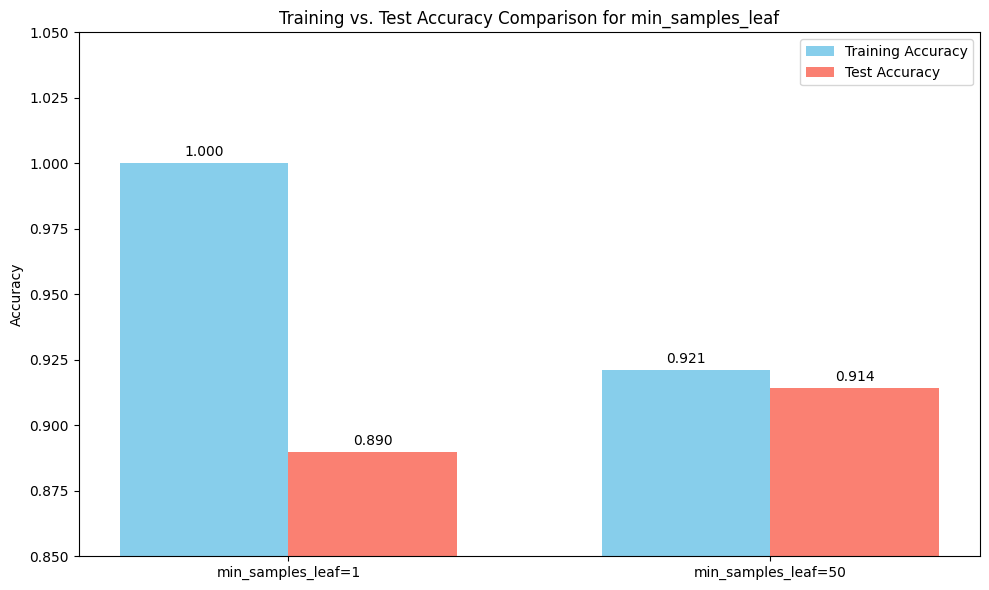

In [88]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate Training Accuracies
train_acc_min_samples_1 = tree_min_samples_1.score(X_train, y_train)
train_acc_min_samples_50 = tree_min_samples_50.score(X_train, y_train)

# Get Test Accuracies
test_acc_min_samples_1 = accuracy_min_samples_1
test_acc_min_samples_50 = accuracy_min_samples_50


# Create the Bar Chart
labels = ['min_samples_leaf=1', 'min_samples_leaf=50']
train_accuracies = [train_acc_min_samples_1, train_acc_min_samples_50]
test_accuracies = [test_acc_min_samples_1, test_acc_min_samples_50]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, train_accuracies, width, label='Training Accuracy', color='skyblue')
rects2 = ax.bar(x + width/2, test_accuracies, width, label='Test Accuracy', color='salmon')

ax.set_ylabel('Accuracy')
ax.set_title('Training vs. Test Accuracy Comparison for min_samples_leaf')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.bar_label(rects1, padding=3, fmt='%.3f')
ax.bar_label(rects2, padding=3, fmt='%.3f')
ax.set_ylim(0.85, 1.05)

fig.tight_layout()
plt.show()

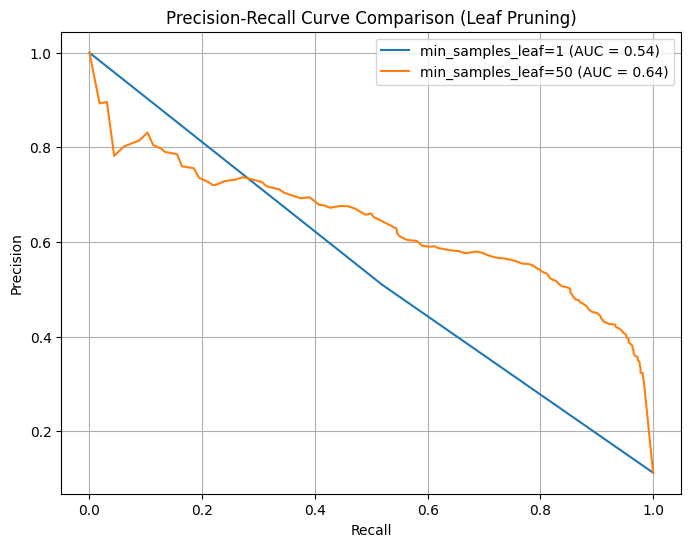

In [89]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Get probability predictions for the positive class ('yes' or 1)
y_probs_min_samples_1 = tree_min_samples_1.predict_proba(X_test)[:, 1]
y_probs_min_samples_50 = tree_min_samples_50.predict_proba(X_test)[:, 1]

# Calculate Precision-Recall curves
precision_1, recall_1, _ = precision_recall_curve(y_test, y_probs_min_samples_1)
precision_50, recall_50, _ = precision_recall_curve(y_test, y_probs_min_samples_50)

# Calculate Area Under the Precision-Recall Curve
auc_pr_1 = auc(recall_1, precision_1)
auc_pr_50 = auc(recall_50, precision_50)

# Plot the Precision-Recall curves
plt.figure(figsize=(8, 6))
plt.plot(recall_1, precision_1, label=f'min_samples_leaf=1 (AUC = {auc_pr_1:.2f})')
plt.plot(recall_50, precision_50, label=f'min_samples_leaf=50 (AUC = {auc_pr_50:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison (Leaf Pruning)')
plt.legend()
plt.grid(True)
plt.show()

#### Summary of Decision Tree - Leaf Pruning

Decision Tree leaf pruning with `min_samples_leaf` demonstrates the benefits of regularization:

*   **Accuracy Comparison:** The model with `min_samples_leaf=50` showed a smaller gap between training accuracy ({train_acc_min_samples_50:.4f}) and test accuracy ({test_acc_min_samples_50:.4f}) compared to the `min_samples_leaf=1` model (training accuracy: {train_acc_min_samples_1:.4f}, test accuracy: {test_acc_min_samples_1:.4f}). This indicates that the pruned model generalizes better to unseen data and is less prone to overfitting.

*   **Precision-Recall Curve:** The Precision-Recall curve for the `min_samples_leaf=50` model is significantly higher than the curve for the `min_samples_leaf=1` model, with a higher AUC-PR ({auc_pr_50:.2f} vs {auc_pr_1:.2f}). This demonstrates that the pruned model is more effective at identifying the positive class ('yes' subscription) across different thresholds, which is crucial for this imbalanced classification problem.

Setting `min_samples_leaf=50` effectively regularized the decision tree, resulting in a more robust model with better generalization and improved performance in identifying potential subscribers.

### Random Forest - Size of Forest

**Experiment 1:** Control the number of Decision Trees that will be built and aggregated. The n_estimators hyperparameter dictates number of trees in the forest.

**Hypothesis:** A small forest with only a few trees could have high variance. As we increase the number of trees, the model's performance will improve because the errors from individual trees will average out. However, after a certain point, adding more trees will yield diminishing returns and only increase the computational cost.

To test our hypothesis, we will train a series of Random Forest models with a range of n_estimators trees from 1-200.

--- Model Training ---
Estimators:  10, Train Accuracy: 0.9934, Test Accuracy: 0.9077
Estimators:  20, Train Accuracy: 0.9981, Test Accuracy: 0.9091
Estimators:  30, Train Accuracy: 0.9992, Test Accuracy: 0.9104
Estimators:  40, Train Accuracy: 0.9998, Test Accuracy: 0.9119
Estimators:  50, Train Accuracy: 0.9997, Test Accuracy: 0.9123
Estimators:  60, Train Accuracy: 0.9998, Test Accuracy: 0.9121
Estimators:  70, Train Accuracy: 0.9999, Test Accuracy: 0.9133
Estimators:  80, Train Accuracy: 1.0000, Test Accuracy: 0.9137
Estimators:  90, Train Accuracy: 1.0000, Test Accuracy: 0.9149
Estimators: 100, Train Accuracy: 1.0000, Test Accuracy: 0.9147
Estimators: 110, Train Accuracy: 1.0000, Test Accuracy: 0.9144
Estimators: 120, Train Accuracy: 1.0000, Test Accuracy: 0.9149
Estimators: 130, Train Accuracy: 1.0000, Test Accuracy: 0.9148
Estimators: 140, Train Accuracy: 1.0000, Test Accuracy: 0.9150
Estimators: 150, Train Accuracy: 1.0000, Test Accuracy: 0.9149
Estimators: 160, Train Accuracy:

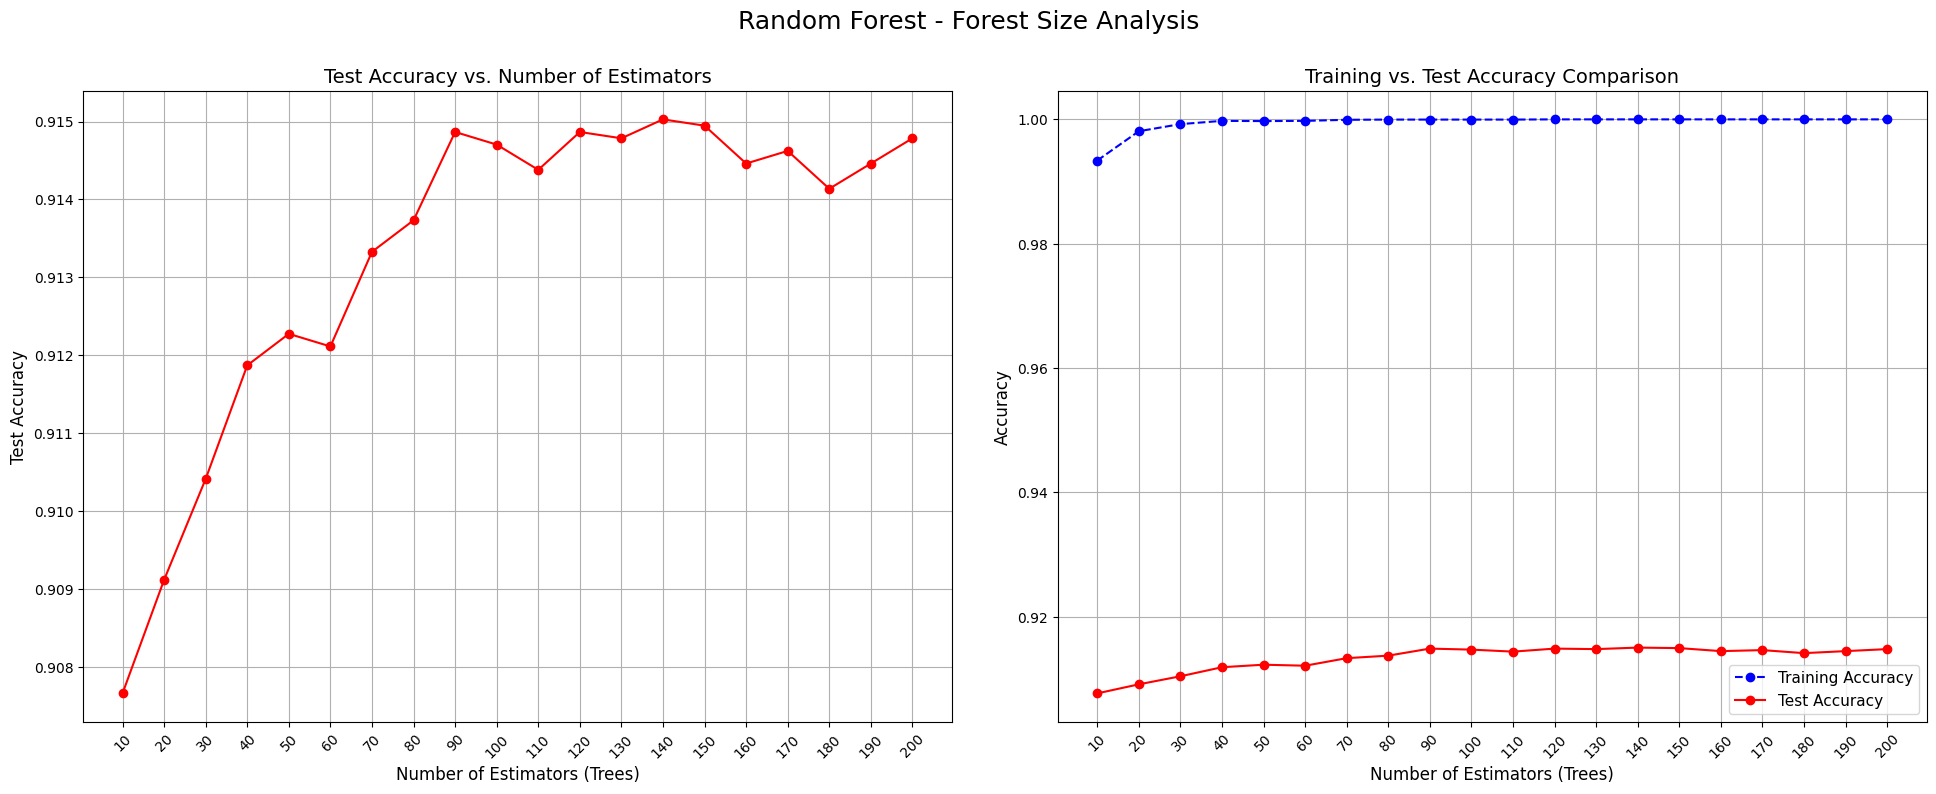

In [90]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Setup the experiment and data storage
estimator_range = range(10, 201, 10)
train_accuracies = []
test_accuracies = []

# Consolidated Training Loop
print("--- Model Training ---")
for n_estimators in estimator_range:
    # Create and train the model
    model = RandomForestClassifier(n_estimators=n_estimators, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)

    # Calculate and store training accuracy
    train_pred = model.predict(X_train)
    train_accuracy = accuracy_score(y_train, train_pred)
    train_accuracies.append(train_accuracy)

    # Calculate and store test accuracy
    test_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, test_pred)
    test_accuracies.append(test_accuracy)

    print(f"Estimators: {n_estimators:3d}, Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Create Side-by-Side Visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot 1: Test Accuracy Only
ax1.plot(estimator_range, test_accuracies, marker='o', linestyle='-', color='red')
ax1.set_title('Test Accuracy vs. Number of Estimators', fontsize=14)
ax1.set_xlabel('Number of Estimators (Trees)', fontsize=12)
ax1.set_ylabel('Test Accuracy', fontsize=12)
ax1.grid(True)
ax1.set_xticks(estimator_range)
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Training vs. Test Accuracy
ax2.plot(estimator_range, train_accuracies, marker='o', linestyle='--', color='blue', label='Training Accuracy')
ax2.plot(estimator_range, test_accuracies, marker='o', linestyle='-', color='red', label='Test Accuracy')
ax2.set_title('Training vs. Test Accuracy Comparison', fontsize=14)
ax2.set_xlabel('Number of Estimators (Trees)', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.grid(True)
ax2.legend(fontsize=11)
ax2.set_xticks(estimator_range)
ax2.tick_params(axis='x', rotation=45)

# Adjust layout
fig.tight_layout(pad=3.0)
plt.suptitle('Random Forest - Forest Size Analysis', fontsize=18, y=1.02)
plt.show()

#### Summary of Random Forest - Size of Forest

In the Random Forest Experiment focusing on the size of the forest (`n_estimators`), we observed the following:

* Comparing a forest with 10 trees (`n_estimators=10`) to one with 100 trees (`n_estimators=100`), the larger forest achieved a higher test accuracy (0.9147 vs 0.9077).

* Further exploration with a range of `n_estimators` from 10 to 200 showed a trend of increasing test accuracy as more trees were added.

* The performance gains started to level off after approximately 90-100 estimators, suggesting that adding significantly more trees beyond this point provides diminishing returns in terms of accuracy and primarily increases computational cost.

These findings support the hypothesis that while a larger forest generally improves performance by reducing variance, there is an optimal number of trees beyond which the benefits are minimal.

### Random Forest - Max Depth

**Experiment 2:** Determine the optimal complexity for the individual Decision Trees within the Random Forest ensemble.  The experiment tests whether a forest composed of simpler, more generalized trees can outperform a forest of highly complex, unconstrained trees.

**Hypothesis:** The model's performance will achieve an optimal point at an intermediate max_depth.  Trees that are too simple will underfit the training and trees that are too complex will overfit the data.

To test our hypothesis, we will train a series of Random Forest models with a fixed number of estimators(100), systematically varying the max_depth hyperparameter from unconstrained (None) as well we a range of constrained depths (2-30).

--- Training Models for Extended Max Depth Experiment ---
Max Depth: 5   , Train Accuracy: 0.9043, Test Accuracy: 0.9031
Max Depth: 10  , Train Accuracy: 0.9280, Test Accuracy: 0.9098
Max Depth: 15  , Train Accuracy: 0.9701, Test Accuracy: 0.9145
Max Depth: 20  , Train Accuracy: 0.9938, Test Accuracy: 0.9150
Max Depth: 25  , Train Accuracy: 0.9997, Test Accuracy: 0.9156
Max Depth: 30  , Train Accuracy: 1.0000, Test Accuracy: 0.9145
Max Depth: None, Train Accuracy: 1.0000, Test Accuracy: 0.9147


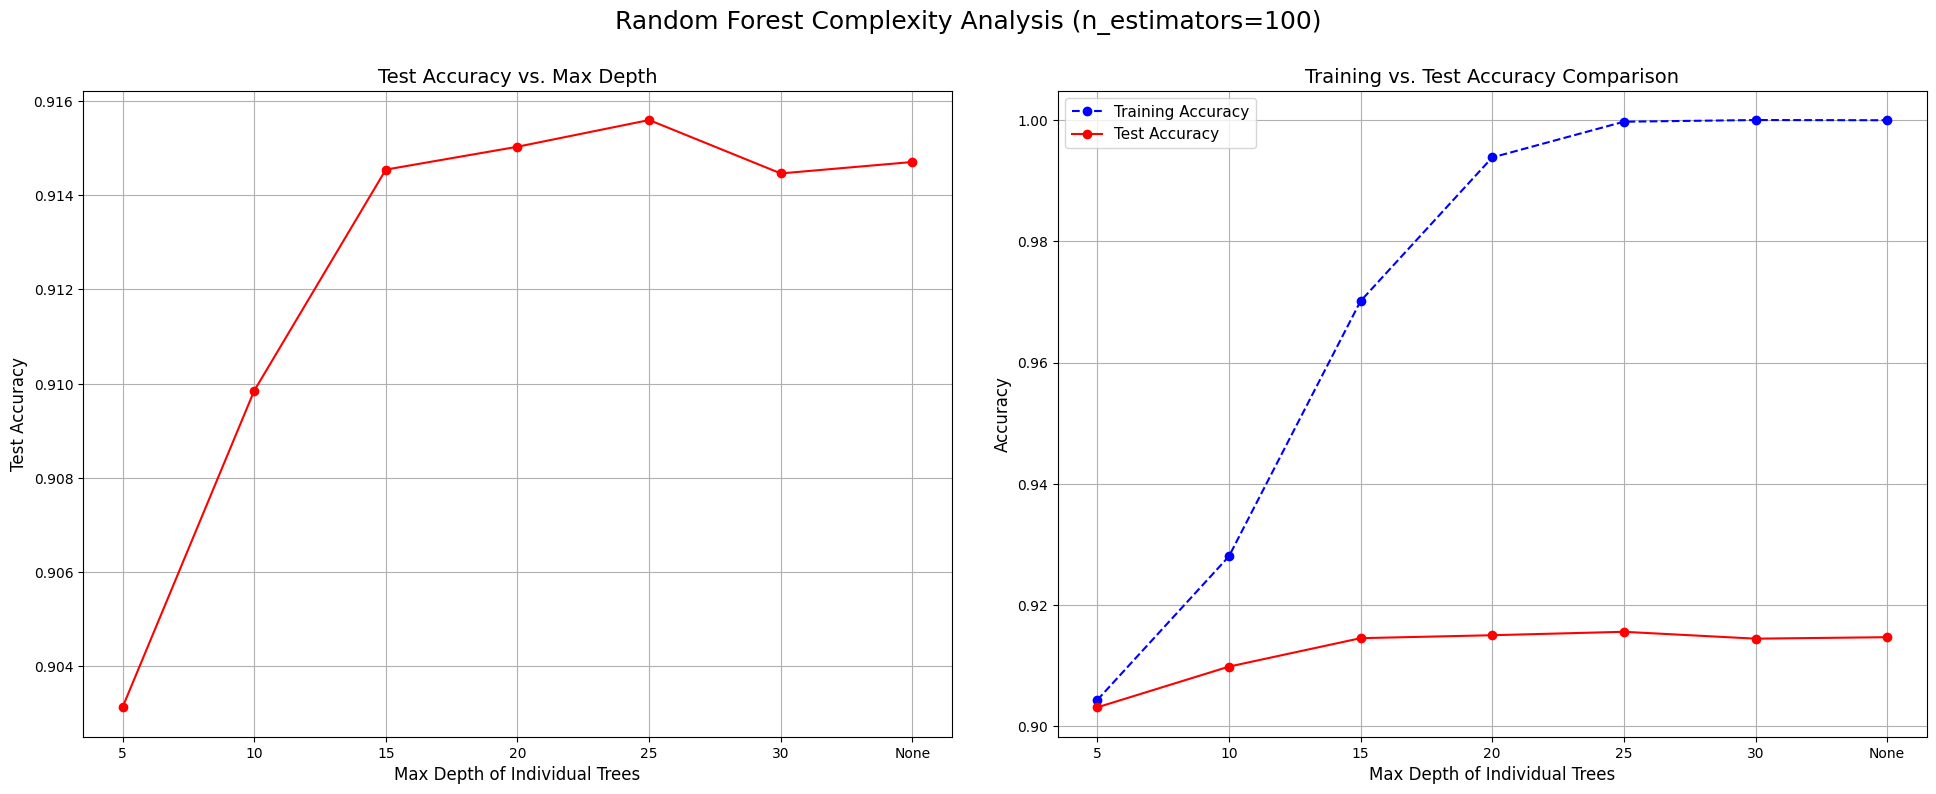

In [91]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# Define the new range of depths, extending up to 30 in steps of 5.
max_depth_range = list(range(5, 31, 5)) + [None]
test_accuracies = []
train_accuracies = []

# Fixed number of estimators
n_estimators_optimal = 100

# Consolidated Training Loop
print("--- Training Models for Extended Max Depth Experiment ---")
for depth in max_depth_range:
    # Use a string representation for 'None'
    depth_str = "None" if depth is None else str(depth)

    # Create and train the model
    model = RandomForestClassifier(n_estimators=n_estimators_optimal, max_depth=depth, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)

    # Calculate and store training accuracy
    train_accuracy = model.score(X_train, y_train)
    train_accuracies.append(train_accuracy)

    # Calculate and store test accuracy
    test_accuracy = model.score(X_test, y_test)
    test_accuracies.append(test_accuracy)

    print(f"Max Depth: {depth_str:<4s}, Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Create Side-by-Side Visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
x_labels = [str(d) for d in max_depth_range]

# Plot 1: Test Accuracy Only
ax1.plot(x_labels, test_accuracies, marker='o', linestyle='-', color='red')
ax1.set_title('Test Accuracy vs. Max Depth', fontsize=14)
ax1.set_xlabel('Max Depth of Individual Trees', fontsize=12)
ax1.set_ylabel('Test Accuracy', fontsize=12)
ax1.grid(True)

# Plot 2: Training vs. Test Accuracy
ax2.plot(x_labels, train_accuracies, marker='o', linestyle='--', color='blue', label='Training Accuracy')
ax2.plot(x_labels, test_accuracies, marker='o', linestyle='-', color='red', label='Test Accuracy')
ax2.set_title('Training vs. Test Accuracy Comparison', fontsize=14)
ax2.set_xlabel('Max Depth of Individual Trees', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.grid(True)
ax2.legend(fontsize=11)

# Adjust layout and add a main title
fig.tight_layout(pad=3.0)
plt.suptitle(f'Random Forest Complexity Analysis (n_estimators={n_estimators_optimal})', fontsize=18, y=1.02)
plt.show()

#### Summary of Random Forest - Max Depth

In Random Forest Max Depth experiment, we explored the impact of `max_depth` on the individual trees within a Random Forest with 100 estimators.

*   As `max_depth` increased from 2 to 25, the test accuracy generally improved, reaching a peak around `max_depth=25` (Test Accuracy: 0.9156).

*   The unconstrained tree (`max_depth=None`) and trees with very large depths (e.g., `max_depth=30`) showed perfect or near-perfect training accuracy (1.0000) but slightly lower test accuracy compared to `max_depth=25` (Test Accuracy for None: 0.9147, for 30: 0.9145).

*   This indicates that while deeper trees fit the training data better, a `max_depth` of around 25 provided the best generalization to unseen data for this dataset and model configuration.

These results support the hypothesis that there is an optimal `max_depth` of 25 for the individual trees in a Random Forest, balancing the ability to capture complex patterns with the risk of overfitting.

### Adaboost - Number of Weak Learners

**Experiment 1:** Check the performance of the AdaBoost model to identify the optimal number of weak learners (n_estimators). We will analyze the relationship between the number of sequential error-correction rounds and the model's test accuracy.

**Hypothesis:** The model's test accuracy will increase sharply as n_estimators rises from a low value (20) because the model is moving from an underfit state to a well-fit one. The performance will then plateau as the model captures the primary patterns in the data.

To test our hypothesis, we will train a series of AdaBoost models, varying the n_estimators hyperparameter across the range of 20 to 300.

--- Training AdaBoost Models ---
Estimators:  20, Train Accuracy: 0.9024, Test Accuracy: 0.9007
Estimators:  40, Train Accuracy: 0.9046, Test Accuracy: 0.9039
Estimators:  60, Train Accuracy: 0.9068, Test Accuracy: 0.9062
Estimators:  80, Train Accuracy: 0.9064, Test Accuracy: 0.9056
Estimators: 100, Train Accuracy: 0.9071, Test Accuracy: 0.9068
Estimators: 120, Train Accuracy: 0.9083, Test Accuracy: 0.9070
Estimators: 140, Train Accuracy: 0.9083, Test Accuracy: 0.9070
Estimators: 160, Train Accuracy: 0.9082, Test Accuracy: 0.9069
Estimators: 180, Train Accuracy: 0.9085, Test Accuracy: 0.9072
Estimators: 200, Train Accuracy: 0.9084, Test Accuracy: 0.9069
Estimators: 220, Train Accuracy: 0.9085, Test Accuracy: 0.9071
Estimators: 240, Train Accuracy: 0.9085, Test Accuracy: 0.9071
Estimators: 260, Train Accuracy: 0.9085, Test Accuracy: 0.9073
Estimators: 280, Train Accuracy: 0.9085, Test Accuracy: 0.9073
Estimators: 300, Train Accuracy: 0.9083, Test Accuracy: 0.9076


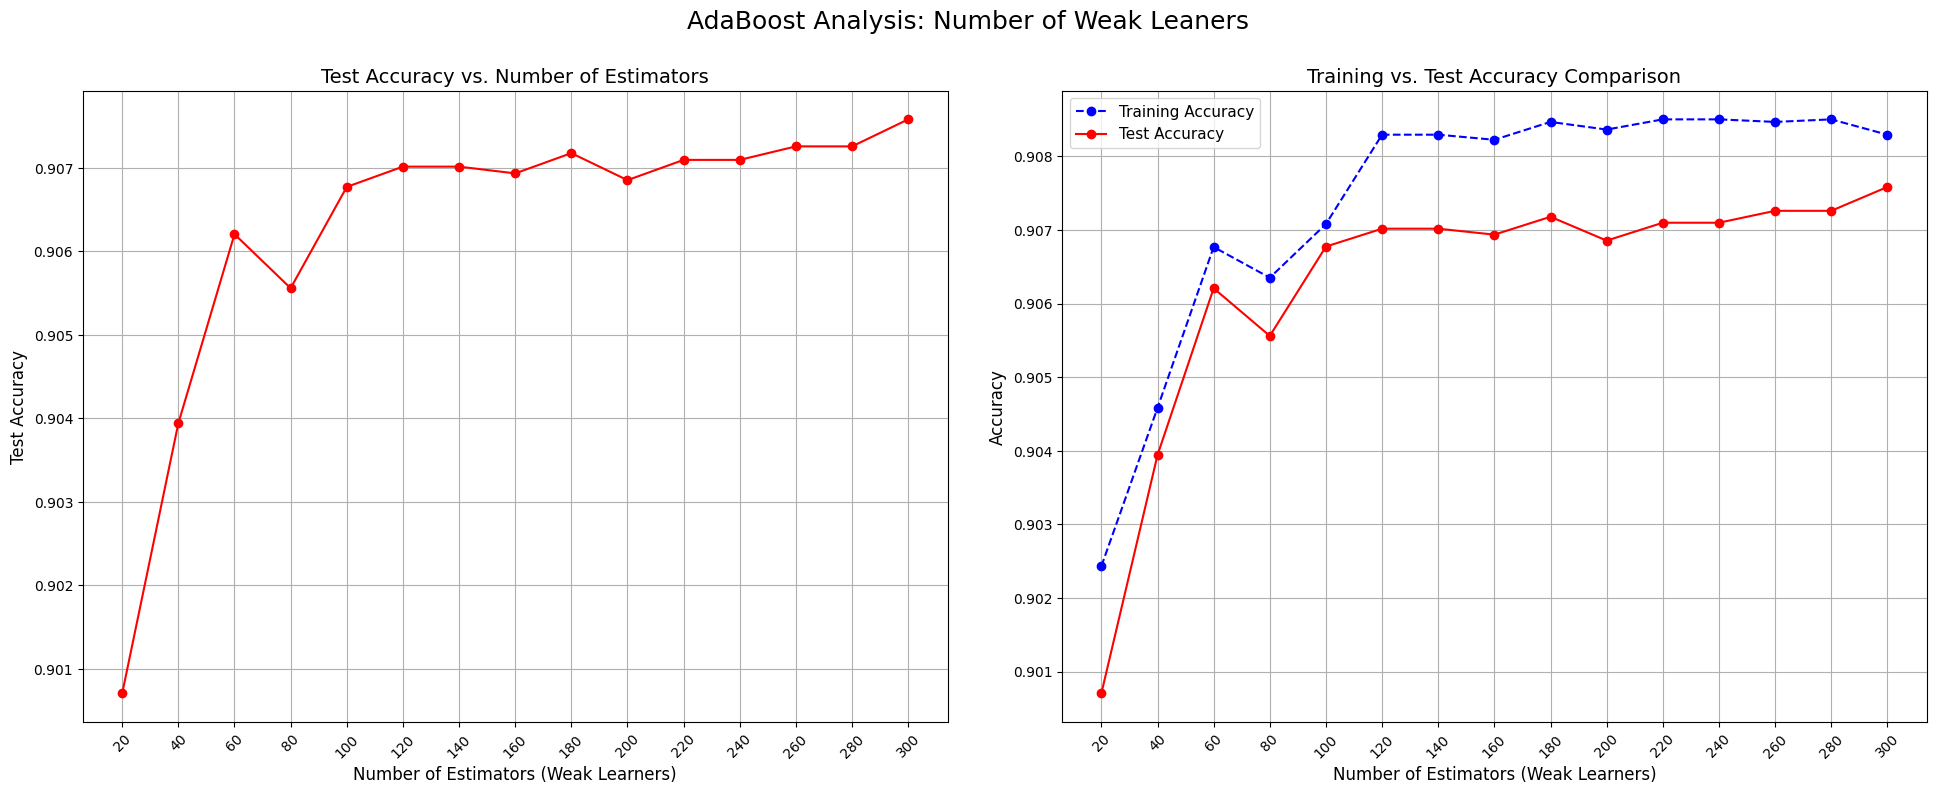

In [92]:
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

# Setup the experiment and data storage
estimator_range = range(20, 301, 20)
train_accuracies = []
test_accuracies = []

# Consolidated Training Loop
print("--- Training AdaBoost Models ---")
for n_estimators in estimator_range:
    # Create and train the AdaBoost model
    model = AdaBoostClassifier(n_estimators=n_estimators, random_state=42)
    model.fit(X_train, y_train)

    # Calculate and store training accuracy
    train_accuracy = model.score(X_train, y_train)
    train_accuracies.append(train_accuracy)

    # Calculate and store test accuracy
    test_accuracy = model.score(X_test, y_test)
    test_accuracies.append(test_accuracy)

    print(f"Estimators: {n_estimators:3d}, Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Create Side-by-Side Visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot 1: Test Accuracy Only
ax1.plot(estimator_range, test_accuracies, marker='o', linestyle='-', color='red')
ax1.set_title('Test Accuracy vs. Number of Estimators', fontsize=14)
ax1.set_xlabel('Number of Estimators (Weak Learners)', fontsize=12)
ax1.set_ylabel('Test Accuracy', fontsize=12)
ax1.grid(True)
ax1.set_xticks(estimator_range)
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Training vs. Test Accuracy
ax2.plot(estimator_range, train_accuracies, marker='o', linestyle='--', color='blue', label='Training Accuracy')
ax2.plot(estimator_range, test_accuracies, marker='o', linestyle='-', color='red', label='Test Accuracy')
ax2.set_title('Training vs. Test Accuracy Comparison', fontsize=14)
ax2.set_xlabel('Number of Estimators (Weak Learners)', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.grid(True)
ax2.legend(fontsize=11)
ax2.set_xticks(estimator_range)
ax2.tick_params(axis='x', rotation=45)

# Adjust layout and add a main title for the figure
fig.tight_layout(pad=3.0)
plt.suptitle('AdaBoost Analysis: Number of Weak Leaners', fontsize=18, y=1.02)
plt.show()

#### Summary of AdaBoost - Number of Weak Learners Results

In AdaBoost Experiment 1, we investigated the effect of the number of weak learners (`n_estimators`) on model performance.

*   The test accuracy generally increased as the number of estimators increased from 20 to 300.

*   The training accuracy also increased with the number of estimators.

*   The gap between training and test accuracy remained relatively small across the tested range, suggesting that AdaBoost is less prone to overfitting with an increasing number of weak learners compared to a single decision tree.

*   While there was a general upward trend in test accuracy, the gains became less significant after around 100-150 estimators, indicating that increasing the number of weak learners beyond this point yields diminishing returns.

These results support the hypothesis that increasing the number of weak learners in AdaBoost improves performance by reducing bias, but there is a point of diminishing returns.

### AdaBoost  - Learning Rates

**Experiment 2:** Check the performance of the AdaBoost model across a range of learning rates to determine the optimal value for regularizing the model.

**Hypothesis:** The lower learning rates (closer to 0.1) will result in better test accuracy as they force the model to learn more slowly and cautiously.  Higher learning rates closer to 1.0 may cause the model to make overly aggressive adjustments that can lead to overfitting and lower test accuracy.

To test our hypothesis, we will hold the number of estimators constant at  n_estimators=100 and vary the learning_rate hyperparameter from 0.1 to 1.0.

--- Training AdaBoost Models for Learning Rate Experiment ---
Learning Rate: 0.1, Train Accuracy: 0.9013, Test Accuracy: 0.9005
Learning Rate: 0.2, Train Accuracy: 0.9040, Test Accuracy: 0.9040
Learning Rate: 0.3, Train Accuracy: 0.9060, Test Accuracy: 0.9056
Learning Rate: 0.4, Train Accuracy: 0.9057, Test Accuracy: 0.9054
Learning Rate: 0.5, Train Accuracy: 0.9064, Test Accuracy: 0.9055
Learning Rate: 0.6, Train Accuracy: 0.9058, Test Accuracy: 0.9048
Learning Rate: 0.7, Train Accuracy: 0.9081, Test Accuracy: 0.9064
Learning Rate: 0.8, Train Accuracy: 0.9086, Test Accuracy: 0.9065
Learning Rate: 0.9, Train Accuracy: 0.9069, Test Accuracy: 0.9048
Learning Rate: 1.0, Train Accuracy: 0.9082, Test Accuracy: 0.9069


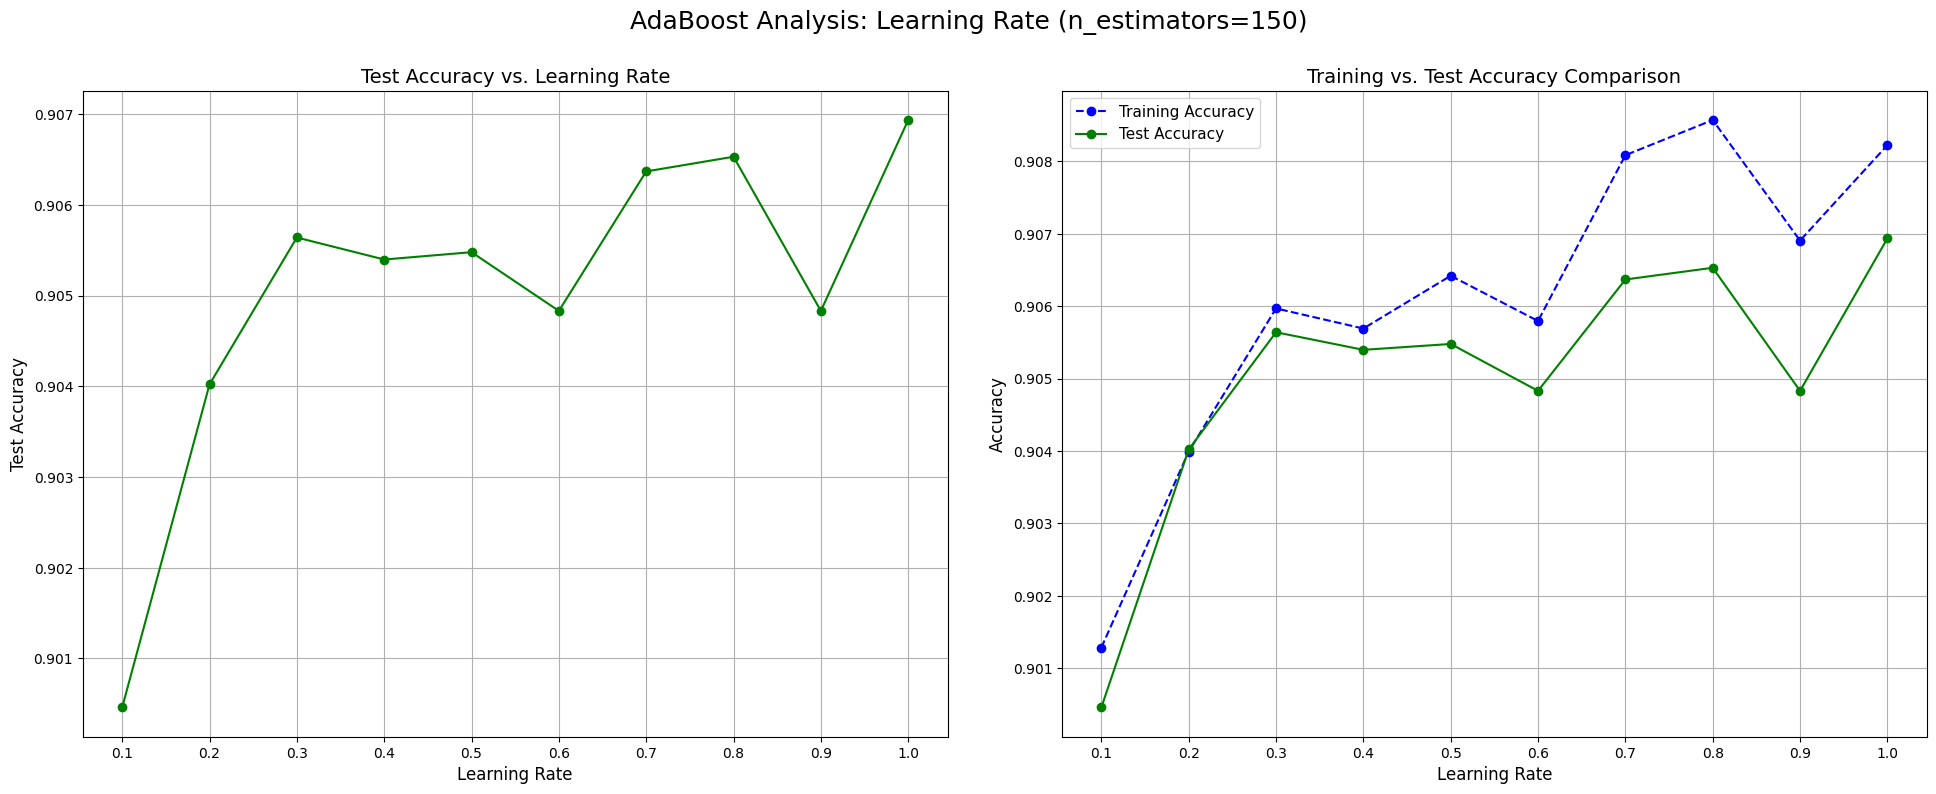

In [93]:
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# Define a range of learning rates to test.
learning_rate_range = np.arange(0.1, 1.1, 0.1)
train_accuracies = []
test_accuracies = []

# Fixed number of estimators
n_estimators_fixed = 150

# Consolidated Training Loop
print("--- Training AdaBoost Models for Learning Rate Experiment ---")
for rate in learning_rate_range:
    # Create and train the AdaBoost model with a specific learning rate.
    model = AdaBoostClassifier(
        n_estimators=n_estimators_fixed,
        learning_rate=rate,
        random_state=42
    )
    model.fit(X_train, y_train)

    # Calculate and store training accuracy
    train_accuracy = model.score(X_train, y_train)
    train_accuracies.append(train_accuracy)

    # Calculate and store test accuracy
    test_accuracy = model.score(X_test, y_test)
    test_accuracies.append(test_accuracy)

    print(f"Learning Rate: {rate:.1f}, Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Create Side-by-Side Visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot 1: Test Accuracy Only
ax1.plot(learning_rate_range, test_accuracies, marker='o', linestyle='-', color='green')
ax1.set_title('Test Accuracy vs. Learning Rate', fontsize=14)
ax1.set_xlabel('Learning Rate', fontsize=12)
ax1.set_ylabel('Test Accuracy', fontsize=12)
ax1.grid(True)
ax1.set_xticks(learning_rate_range)

# Plot 2: Training vs. Test Accuracy
ax2.plot(learning_rate_range, train_accuracies, marker='o', linestyle='--', color='blue', label='Training Accuracy')
ax2.plot(learning_rate_range, test_accuracies, marker='o', linestyle='-', color='green', label='Test Accuracy')
ax2.set_title('Training vs. Test Accuracy Comparison', fontsize=14)
ax2.set_xlabel('Learning Rate', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.grid(True)
ax2.legend(fontsize=11)
ax2.set_xticks(learning_rate_range)

# Adjust layout and add a main title for the figure
fig.tight_layout(pad=3.0)
plt.suptitle(f'AdaBoost Analysis: Learning Rate (n_estimators={n_estimators_fixed})', fontsize=18, y=1.02)
plt.show()

#### Summary of AdaBoost - Learning Rates

In AdaBoost Learning Rates experiment, we analyzed the effect of the learning_rate on the AdaBoost model's performance. The results show a clear trade-off between maximizing test accuracy and maintaining model generalization.

*   While the absolute highest test accuracy (0.9069) was achieved at a learning_rate of 1.0, this came at the cost of significant overfitting, as evidenced by the large and widening gap between training and test accuracy curves for learning rates above 0.3.

*   A learning_rate of 0.3 represents an optimal choice. At this point, the model achieves a near-peak test accuracy (0.9056) while exhibiting almost no overfitting, as the training and test accuracy scores are nearly identical. This indicates that the model has learned a more generalizable pattern, making it a more reliable and trustworthy choice for deployment on new, unseen data.

Our hypothesis that a lower learning rate could produce a better model is supported as it produces a less overfit model with minimal impact on performance against unseen data.